# Bank Customer Churn Prediction Using PySpark

## Project Structure

This project follows a structured Data Processing, Data Analysis, Feature Engineering, and Machine Learning workflow using PySpark.

### 1. Spark Setup

* Import the required PySpark libraries.
* Create a SparkSession.
* Check the Spark version.

### 2. Data Loading

* Load the Bank Customer Churn dataset into a Spark DataFrame.
* Inspect the number of rows and columns.
* Display the dataset schema and sample records.

### 3. Data Exploration

* Analyze the structure and statistical summary of the dataset.
* Check the distribution of the target variable (`churn`).
* Analyze customer churn based on selected features such as country, gender, age, and active membership.

### 4. Data Cleaning and Validation

* Check for missing values.
* Check for duplicate records.
* Validate important columns and identify invalid values.
* Remove `customer_id` because it is only an identifier and does not contribute to prediction.

### 5. Feature Engineering

* Identify numerical and categorical features.
* Convert categorical features using `StringIndexer`.
* Apply `OneHotEncoder` to categorical features.
* Combine the input features into a single feature vector using `VectorAssembler`.

### 6. Train-Test Split

* Split the prepared dataset into training and testing sets.
* Use the training set to build the models.
* Use the testing set to evaluate their performance.

### 7. Machine Learning Models

Train and compare three classification models using PySpark ML:

* Logistic Regression
* Decision Tree Classifier
* Random Forest Classifier

### 8. PySpark ML Pipelines

* Build a separate ML Pipeline for each model.
* Combine preprocessing steps and the classification algorithm into one workflow.
* Train each pipeline on the training dataset.
* Generate predictions on the test dataset.

### 9. Model Evaluation

Evaluate each model using:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC

### 10. Model Comparison

* Compare the performance of all trained models.
* Identify the best-performing model based on the evaluation metrics.

### 11. Feature Importance

* Analyze the most important features used by the Random Forest model for predicting customer churn.

## Main Objective

The main objective of this project is to use PySpark for data processing, feature engineering, and machine learning to predict whether a bank customer is likely to leave the bank (`churn = 1`) or remain with the bank (`churn = 0`).


In [61]:
!pip install pyspark

In [62]:
# ==========================================
# 1. Spark Setup and Required Libraries
# ==========================================

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

# PySpark ML Pipeline and feature preprocessing
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

# Classification models
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier
)

# Model evaluation
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)


# Create Spark Session
spark = SparkSession.builder \
    .appName("Bank Customer Churn Prediction") \
    .getOrCreate()

print("Spark Version:", spark.version)

Spark Version: 4.0.4


In [63]:
# ==========================================
# 2. Data Loading
# ==========================================

df = spark.read.csv(
    "/content/Bank Customer Churn Prediction.csv",
    header=True,
    inferSchema=True
)

# Display sample records
df.show(10, truncate=False)

+-----------+------------+-------+------+---+------+---------+---------------+-----------+-------------+----------------+-----+
|customer_id|credit_score|country|gender|age|tenure|balance  |products_number|credit_card|active_member|estimated_salary|churn|
+-----------+------------+-------+------+---+------+---------+---------------+-----------+-------------+----------------+-----+
|15634602   |619         |France |Female|42 |2     |0.0      |1              |1          |1            |101348.88       |1    |
|15647311   |608         |Spain  |Female|41 |1     |83807.86 |1              |0          |1            |112542.58       |0    |
|15619304   |502         |France |Female|42 |8     |159660.8 |3              |1          |0            |113931.57       |1    |
|15701354   |699         |France |Female|39 |1     |0.0      |2              |0          |0            |93826.63        |0    |
|15737888   |850         |Spain  |Female|43 |2     |125510.82|1              |1          |1            |

In [64]:
# ==========================================
# 3. Initial Data Inspection
# ==========================================

print("Number of Rows:", df.count())
print("Number of Columns:", len(df.columns))

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
df.printSchema()

Number of Rows: 10000
Number of Columns: 12

Column Names:
['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

Data Types:
root
 |-- customer_id: integer (nullable = true)
 |-- credit_score: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- balance: double (nullable = true)
 |-- products_number: integer (nullable = true)
 |-- credit_card: integer (nullable = true)
 |-- active_member: integer (nullable = true)
 |-- estimated_salary: double (nullable = true)
 |-- churn: integer (nullable = true)



In [65]:
# ==========================================
# 4. Statistical Summary
# ==========================================

df.describe().show()

+-------+-----------------+-----------------+-------+------+------------------+------------------+-----------------+------------------+-------------------+-------------------+-----------------+-------------------+
|summary|      customer_id|     credit_score|country|gender|               age|            tenure|          balance|   products_number|        credit_card|      active_member| estimated_salary|              churn|
+-------+-----------------+-----------------+-------+------+------------------+------------------+-----------------+------------------+-------------------+-------------------+-----------------+-------------------+
|  count|            10000|            10000|  10000| 10000|             10000|             10000|            10000|             10000|              10000|              10000|            10000|              10000|
|   mean|  1.56909405694E7|         650.5288|   NULL|  NULL|           38.9218|            5.0128|76485.88928799961|            1.5302|         

In [66]:
# ==========================================
# 5. Missing Values Check
# ==========================================

print("=== Missing Values ===")

for column in df.columns:
    missing = df.filter(col(column).isNull()).count()
    print(f"{column}: {missing}")

=== Missing Values ===
customer_id: 0
credit_score: 0
country: 0
gender: 0
age: 0
tenure: 0
balance: 0
products_number: 0
credit_card: 0
active_member: 0
estimated_salary: 0
churn: 0


In [67]:
# ==========================================
# 6. Duplicate Records Check
# ==========================================

total_rows = df.count()

distinct_rows = df.distinct().count()

print("Total Rows:", total_rows)
print("Distinct Rows:", distinct_rows)
print("Duplicate Rows:", total_rows - distinct_rows)

Total Rows: 10000
Distinct Rows: 10000
Duplicate Rows: 0


In [68]:
# ==========================================
# 7. Data Validation
# ==========================================

print("=== Invalid Values Check ===")

print("Invalid Credit Scores:",
      df.filter((col("credit_score") < 350) | (col("credit_score") > 850)).count())

print("Invalid Ages:",
      df.filter((col("age") < 18) | (col("age") > 100)).count())

print("Invalid Tenure:",
      df.filter((col("tenure") < 0) | (col("tenure") > 10)).count())

print("Invalid Products Number:",
      df.filter((col("products_number") < 1) | (col("products_number") > 4)).count())

print("Invalid Credit Card Values:",
      df.filter(~col("credit_card").isin(0, 1)).count())

print("Invalid Active Member Values:",
      df.filter(~col("active_member").isin(0, 1)).count())

print("Invalid Churn Values:",
      df.filter(~col("churn").isin(0, 1)).count())

=== Invalid Values Check ===
Invalid Credit Scores: 0
Invalid Ages: 0
Invalid Tenure: 0
Invalid Products Number: 0
Invalid Credit Card Values: 0
Invalid Active Member Values: 0
Invalid Churn Values: 0


In [69]:
# ==========================================
# 8. Categorical Data Distribution
# ==========================================

categorical_columns = ["country", "gender"]

for column in categorical_columns:

    print(f"\n=== {column.upper()} ===")

    df.groupBy(column) \
        .count() \
        .orderBy(desc("count")) \
        .show()


=== COUNTRY ===
+-------+-----+
|country|count|
+-------+-----+
| France| 5014|
|Germany| 2509|
|  Spain| 2477|
+-------+-----+


=== GENDER ===
+------+-----+
|gender|count|
+------+-----+
|  Male| 5457|
|Female| 4543|
+------+-----+



In [70]:
# ==========================================
# 9. Churn Distribution
# ==========================================

print("=== Churn Distribution ===")

total = df.count()

df.groupBy("churn") \
    .count() \
    .withColumn(
        "percentage",
        round(col("count") / total * 100, 2)
    ) \
    .orderBy("churn") \
    .show()

=== Churn Distribution ===
+-----+-----+----------+
|churn|count|percentage|
+-----+-----+----------+
|    0| 7963|     79.63|
|    1| 2037|     20.37|
+-----+-----+----------+



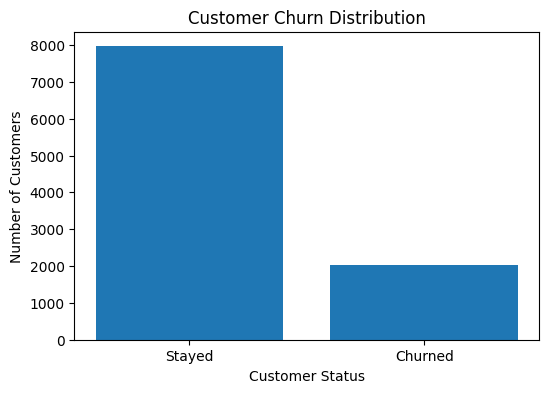

In [71]:
# ==========================================
# 10. Churn Distribution Visualization
# ==========================================

import matplotlib.pyplot as plt

churn_data = df.groupBy("churn") \
    .count() \
    .orderBy("churn") \
    .toPandas()

churn_labels = ["Stayed", "Churned"]

plt.figure(figsize=(6, 4))

plt.bar(
    churn_labels,
    churn_data["count"]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

In [72]:
# ==========================================
# 11. Churn by Country
# ==========================================

print("=== Churn by Country ===")

df.groupBy("country", "churn") \
    .count() \
    .orderBy("country", "churn") \
    .show()

=== Churn by Country ===
+-------+-----+-----+
|country|churn|count|
+-------+-----+-----+
| France|    0| 4204|
| France|    1|  810|
|Germany|    0| 1695|
|Germany|    1|  814|
|  Spain|    0| 2064|
|  Spain|    1|  413|
+-------+-----+-----+



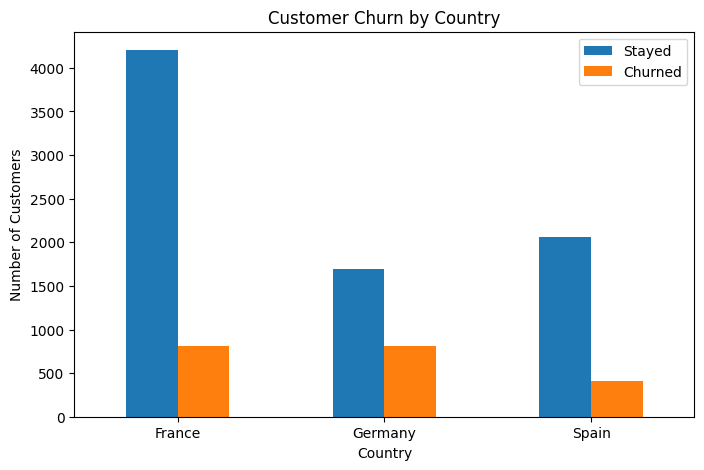

In [73]:
# ==========================================
# 12. Churn by Country Visualization
# ==========================================

country_data = df.groupBy("country", "churn") \
    .count() \
    .orderBy("country", "churn") \
    .toPandas()

country_pivot = country_data.pivot(
    index="country",
    columns="churn",
    values="count"
).fillna(0)

country_pivot.columns = ["Stayed", "Churned"]

country_pivot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Customer Churn by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [74]:
# ==========================================
# 13. Churn by Gender
# ==========================================

print("=== Churn by Gender ===")

df.groupBy("gender", "churn") \
    .count() \
    .orderBy("gender", "churn") \
    .show()

=== Churn by Gender ===
+------+-----+-----+
|gender|churn|count|
+------+-----+-----+
|Female|    0| 3404|
|Female|    1| 1139|
|  Male|    0| 4559|
|  Male|    1|  898|
+------+-----+-----+



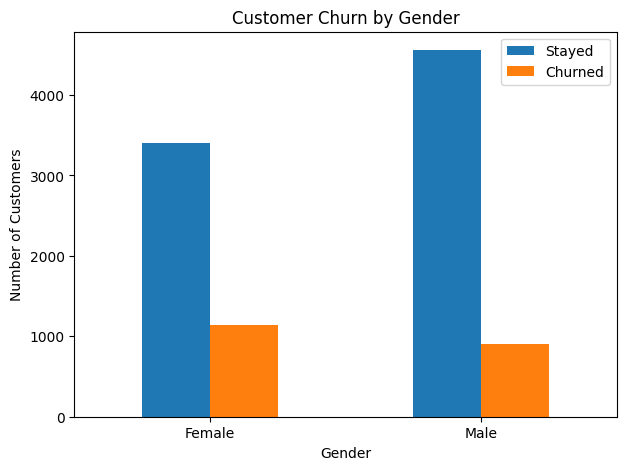

In [75]:
# ==========================================
# 14. Churn by Gender Visualization
# ==========================================

gender_data = df.groupBy("gender", "churn") \
    .count() \
    .orderBy("gender", "churn") \
    .toPandas()

gender_pivot = gender_data.pivot(
    index="gender",
    columns="churn",
    values="count"
).fillna(0)

gender_pivot.columns = ["Stayed", "Churned"]

gender_pivot.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [76]:
# ==========================================
# 15. Average Customer Statistics by Churn
# ==========================================

print("=== Average Customer Statistics by Churn ===")

df.groupBy("churn") \
    .agg(
        round(avg("age"), 2).alias("average_age"),
        round(avg("credit_score"), 2).alias("average_credit_score"),
        round(avg("balance"), 2).alias("average_balance"),
        round(avg("estimated_salary"), 2).alias("average_salary"),
        round(avg("tenure"), 2).alias("average_tenure"),
        round(avg("products_number"), 2).alias("average_products")
    ) \
    .orderBy("churn") \
    .show()

=== Average Customer Statistics by Churn ===
+-----+-----------+--------------------+---------------+--------------+--------------+----------------+
|churn|average_age|average_credit_score|average_balance|average_salary|average_tenure|average_products|
+-----+-----------+--------------------+---------------+--------------+--------------+----------------+
|    0|      37.41|              651.85|        72745.3|      99738.39|          5.03|            1.54|
|    1|      44.84|              645.35|       91108.54|     101465.68|          4.93|            1.48|
+-----+-----------+--------------------+---------------+--------------+--------------+----------------+



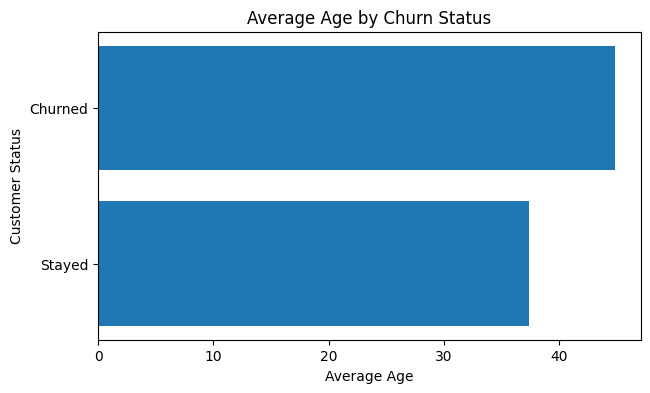

In [77]:
# ==========================================
# 16. Average Age by Churn Visualization
# ==========================================

age_data = df.groupBy("churn") \
    .agg(
        round(avg("age"), 2).alias("average_age")
    ) \
    .orderBy("churn") \
    .toPandas()

age_labels = ["Stayed", "Churned"]

plt.figure(figsize=(7, 4))

plt.barh(
    age_labels,
    age_data["average_age"]
)

plt.title("Average Age by Churn Status")
plt.xlabel("Average Age")
plt.ylabel("Customer Status")

plt.show()

In [78]:
# ==========================================
# 17. Churn by Active Member
# ==========================================

print("=== Churn by Active Member ===")

df.groupBy("active_member", "churn") \
    .count() \
    .orderBy("active_member", "churn") \
    .show()

=== Churn by Active Member ===
+-------------+-----+-----+
|active_member|churn|count|
+-------------+-----+-----+
|            0|    0| 3547|
|            0|    1| 1302|
|            1|    0| 4416|
|            1|    1|  735|
+-------------+-----+-----+



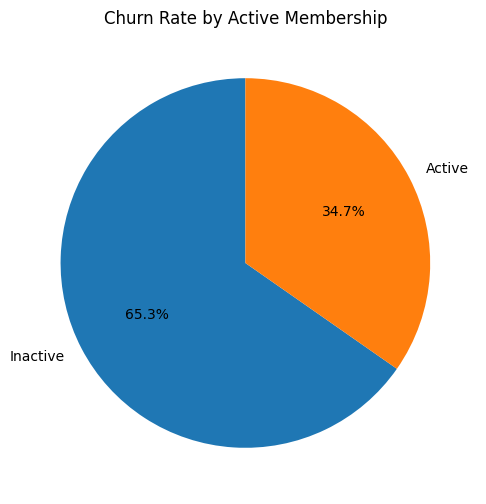

In [79]:
# ==========================================
# 18. Churn Rate by Active Membership
# ==========================================

active_data = df.groupBy("active_member") \
    .agg(
        count("*").alias("total_customers"),
        sum("churn").alias("churned_customers")
    ) \
    .withColumn(
        "churn_rate",
        round(
            col("churned_customers") / col("total_customers") * 100,
            2
        )
    ) \
    .orderBy("active_member") \
    .toPandas()

active_labels = ["Inactive", "Active"]

plt.figure(figsize=(6, 6))

plt.pie(
    active_data["churn_rate"],
    labels=active_labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Churn Rate by Active Membership")

plt.show()

In [80]:
# ==========================================
# 19. Feature Preparation
# ==========================================

def prepare_features(df):
    # Remove customer_id because it is only an identifier
    df_prepared = df.drop("customer_id")

    print("=== Features After Preparation ===")
    print(df_prepared.columns)

    return df_prepared


df_prepared = prepare_features(df_clean)

df_prepared.show(5, truncate=False)

=== Features After Preparation ===
['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']
+------------+-------+------+---+------+---------+---------------+-----------+-------------+----------------+-----+
|credit_score|country|gender|age|tenure|balance  |products_number|credit_card|active_member|estimated_salary|churn|
+------------+-------+------+---+------+---------+---------------+-----------+-------------+----------------+-----+
|619         |France |Female|42 |2     |0.0      |1              |1          |1            |101348.88       |1    |
|608         |Spain  |Female|41 |1     |83807.86 |1              |0          |1            |112542.58       |0    |
|502         |France |Female|42 |8     |159660.8 |3              |1          |0            |113931.57       |1    |
|699         |France |Female|39 |1     |0.0      |2              |0          |0            |93826.63        |0    |
|850   

In [81]:
# ==========================================
# 20. Feature Engineering & Encoding
# ==========================================

categorical_columns = ["country", "gender"]

numeric_columns = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "credit_card",
    "active_member",
    "estimated_salary"
]

# Encode categorical columns
country_indexer = StringIndexer(
    inputCol="country",
    outputCol="country_index",
    handleInvalid="keep"
)

gender_indexer = StringIndexer(
    inputCol="gender",
    outputCol="gender_index",
    handleInvalid="keep"
)

# One-hot encoding
encoder = OneHotEncoder(
    inputCols=["country_index", "gender_index"],
    outputCols=["country_vec", "gender_vec"]
)

# Combine all features into one vector
assembler = VectorAssembler(
    inputCols=[
        "credit_score",
        "age",
        "tenure",
        "balance",
        "products_number",
        "credit_card",
        "active_member",
        "estimated_salary",
        "country_vec",
        "gender_vec"
    ],
    outputCol="features"
)

print("Categorical columns:", categorical_columns)
print("Numeric columns:", numeric_columns)
print("Feature engineering components created successfully.")

Categorical columns: ['country', 'gender']
Numeric columns: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']
Feature engineering components created successfully.


In [82]:
# ==========================================
# 21. Train / Test Split
# ==========================================

train_df, test_df = df_prepared.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())

Training rows: 8079
Testing rows: 1921


In [83]:
# ==========================================
# 22. Logistic Regression
# ==========================================

logistic_regression = LogisticRegression(
    featuresCol="features",
    labelCol="churn",
    maxIter=100
)

lr_pipeline = Pipeline(
    stages=[
        country_indexer,
        gender_indexer,
        encoder,
        assembler,
        logistic_regression
    ]
)

lr_model = lr_pipeline.fit(train_df)

lr_predictions = lr_model.transform(test_df)

print("=== Logistic Regression Predictions ===")

lr_predictions.select(
    "churn",
    "prediction",
    "probability"
).show(10, truncate=False)

=== Logistic Regression Predictions ===
+-----+----------+----------------------------------------+
|churn|prediction|probability                             |
+-----+----------+----------------------------------------+
|1    |0.0       |[0.8566863587961295,0.14331364120387047]|
|1    |1.0       |[0.46958680070326436,0.5304131992967356]|
|1    |0.0       |[0.8313174296781678,0.1686825703218322] |
|1    |0.0       |[0.7214354470405017,0.27856455295949833]|
|1    |1.0       |[0.4375859565776542,0.5624140434223458] |
|1    |0.0       |[0.9337365460159331,0.06626345398406686]|
|0    |0.0       |[0.9185477313719673,0.08145226862803268]|
|0    |0.0       |[0.815948443720707,0.18405155627929304] |
|0    |0.0       |[0.8542323834904709,0.14576761650952907]|
|0    |0.0       |[0.8909541422273355,0.10904585777266451]|
+-----+----------+----------------------------------------+
only showing top 10 rows


In [84]:
# ==========================================
# 23. Evaluation Function
# ==========================================

from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col


def evaluate_model(predictions, model_name):

    accuracy_evaluator = MulticlassClassificationEvaluator(
        labelCol="churn",
        predictionCol="prediction",
        metricName="accuracy"
    )

    precision_evaluator = MulticlassClassificationEvaluator(
        labelCol="churn",
        predictionCol="prediction",
        metricName="weightedPrecision"
    )

    recall_evaluator = MulticlassClassificationEvaluator(
        labelCol="churn",
        predictionCol="prediction",
        metricName="weightedRecall"
    )

    f1_evaluator = MulticlassClassificationEvaluator(
        labelCol="churn",
        predictionCol="prediction",
        metricName="f1"
    )

    predictions = predictions.withColumn(
        "churn_probability",
        vector_to_array(col("probability"))[1]
    )

    roc_evaluator = BinaryClassificationEvaluator(
        labelCol="churn",
        rawPredictionCol="churn_probability",
        metricName="areaUnderROC"
    )

    accuracy = accuracy_evaluator.evaluate(predictions)
    precision = precision_evaluator.evaluate(predictions)
    recall = recall_evaluator.evaluate(predictions)
    f1 = f1_evaluator.evaluate(predictions)
    roc_auc = roc_evaluator.evaluate(predictions)

    print(f"=== {model_name} Results ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

In [85]:
# ==========================================
# 24. Logistic Regression Evaluation
# ==========================================

lr_results = evaluate_model(
    lr_predictions,
    "Logistic Regression"
)

=== Logistic Regression Results ===
Accuracy:  0.8116
Precision: 0.7883
Recall:    0.8116
F1-Score:  0.7737
ROC-AUC:   0.7620


In [86]:
# ==========================================
# 25. Decision Tree
# ==========================================

decision_tree = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="churn",
    maxDepth=5,
    seed=42
)

dt_pipeline = Pipeline(
    stages=[
        country_indexer,
        gender_indexer,
        encoder,
        assembler,
        decision_tree
    ]
)

dt_model = dt_pipeline.fit(train_df)

dt_predictions = dt_model.transform(test_df)

print("=== Decision Tree Predictions ===")

dt_predictions.select(
    "churn",
    "prediction",
    "probability"
).show(10, truncate=False)

dt_results = evaluate_model(
    dt_predictions,
    "Decision Tree"
)

=== Decision Tree Predictions ===
+-----+----------+----------------------------------------+
|churn|prediction|probability                             |
+-----+----------+----------------------------------------+
|1    |0.0       |[0.7336065573770492,0.26639344262295084]|
|1    |1.0       |[0.13131313131313133,0.8686868686868687]|
|1    |1.0       |[0.05263157894736842,0.9473684210526315]|
|1    |1.0       |[0.05263157894736842,0.9473684210526315]|
|1    |1.0       |[0.39485981308411217,0.6051401869158879]|
|1    |0.0       |[0.8986980560014268,0.10130194399857322]|
|0    |0.0       |[0.8986980560014268,0.10130194399857322]|
|0    |0.0       |[0.8986980560014268,0.10130194399857322]|
|0    |0.0       |[0.8986980560014268,0.10130194399857322]|
|0    |0.0       |[0.8986980560014268,0.10130194399857322]|
+-----+----------+----------------------------------------+
only showing top 10 rows
=== Decision Tree Results ===
Accuracy:  0.8438
Precision: 0.8321
Recall:    0.8438
F1-Score:  0.8330

In [87]:
# ==========================================
# 26. Random Forest
# ==========================================

random_forest = RandomForestClassifier(
    featuresCol="features",
    labelCol="churn",
    numTrees=100,
    maxDepth=8,
    seed=42
)

rf_pipeline = Pipeline(
    stages=[
        country_indexer,
        gender_indexer,
        encoder,
        assembler,
        random_forest
    ]
)

rf_model = rf_pipeline.fit(train_df)

rf_predictions = rf_model.transform(test_df)

print("=== Random Forest Predictions ===")

rf_predictions.select(
    "churn",
    "prediction",
    "probability"
).show(10, truncate=False)

rf_results = evaluate_model(
    rf_predictions,
    "Random Forest"
)

=== Random Forest Predictions ===
+-----+----------+-----------------------------------------+
|churn|prediction|probability                              |
+-----+----------+-----------------------------------------+
|1    |0.0       |[0.6967364387638422,0.30326356123615783] |
|1    |1.0       |[0.061482160125539906,0.9385178398744601]|
|1    |1.0       |[0.196737267514942,0.8032627324850581]   |
|1    |1.0       |[0.3405466968469563,0.6594533031530436]  |
|1    |1.0       |[0.210614180513701,0.789385819486299]    |
|1    |0.0       |[0.8707537525315827,0.12924624746841717] |
|0    |0.0       |[0.945163850408992,0.054836149591008035] |
|0    |0.0       |[0.8552986370412813,0.14470136295871863] |
|0    |0.0       |[0.8664323196063516,0.13356768039364844] |
|0    |0.0       |[0.942318908883298,0.05768109111670194]  |
+-----+----------+-----------------------------------------+
only showing top 10 rows
=== Random Forest Results ===
Accuracy:  0.8532
Precision: 0.8445
Recall:    0.8532
F1-

In [88]:
# ==========================================
# 27. Model Comparison
# ==========================================

all_results = [
    lr_results,
    dt_results,
    rf_results
]

print("=== Model Comparison ===")

for result in all_results:
    print(f"\n{result['Model']}")
    print(f"Accuracy:  {result['Accuracy']:.4f}")
    print(f"Precision: {result['Precision']:.4f}")
    print(f"Recall:    {result['Recall']:.4f}")
    print(f"F1-Score:  {result['F1-Score']:.4f}")
    print(f"ROC-AUC:   {result['ROC-AUC']:.4f}")

=== Model Comparison ===

Logistic Regression
Accuracy:  0.8116
Precision: 0.7883
Recall:    0.8116
F1-Score:  0.7737
ROC-AUC:   0.7620

Decision Tree
Accuracy:  0.8438
Precision: 0.8321
Recall:    0.8438
F1-Score:  0.8330
ROC-AUC:   0.7569

Random Forest
Accuracy:  0.8532
Precision: 0.8445
Recall:    0.8532
F1-Score:  0.8369
ROC-AUC:   0.8536


=== Random Forest Feature Importance ===
         Feature  Importance
             age    0.366780
 products_number    0.288465
   active_member    0.083485
         balance    0.066279
estimated_salary    0.038920
    credit_score    0.037872
          tenure    0.025257
     country_vec    0.009385
     credit_card    0.005941
      gender_vec    0.004911


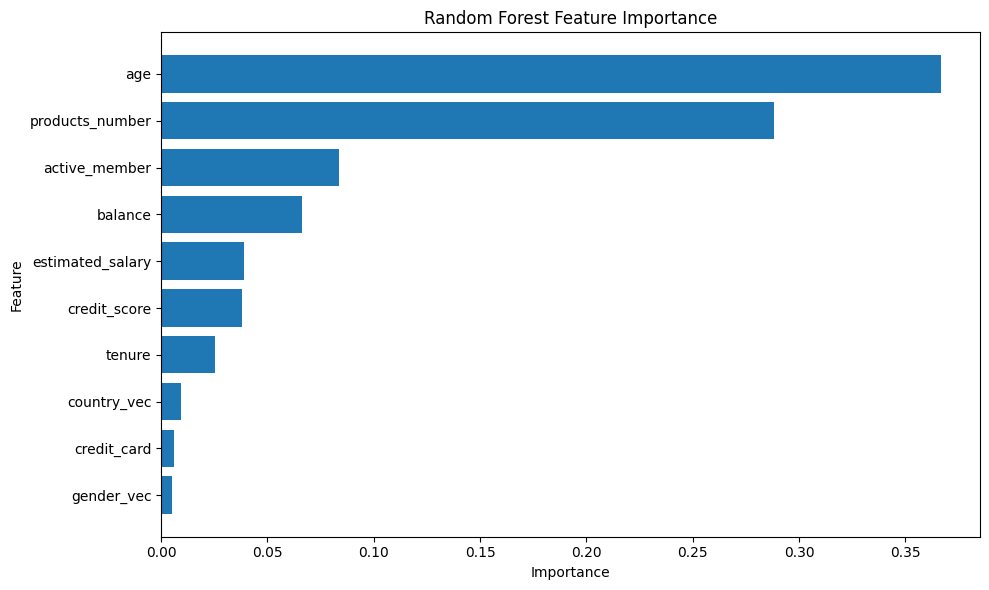

In [89]:
# ==========================================
# 28. Random Forest Feature Importance
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt


# Get the trained Random Forest model
rf_classifier = rf_model.stages[-1]

# Get feature importance values
importances = rf_classifier.featureImportances


# Get feature names after encoding
feature_names = assembler.getInputCols()

importance_data = []

for feature, importance in zip(feature_names, importances):
    importance_data.append({
        "Feature": feature,
        "Importance": importance
    })


# Create DataFrame
importance_df = pd.DataFrame(importance_data)

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)


# Display results
print("=== Random Forest Feature Importance ===")

print(
    importance_df.to_string(index=False)
)


# ==========================================
# Plot Feature Importance
# ==========================================

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

=== Model Comparison Table ===
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.811556   0.788313 0.811556  0.773716 0.761984
      Decision Tree  0.843831   0.832115 0.843831  0.833047 0.756937
      Random Forest  0.853201   0.844497 0.853201  0.836919 0.853597


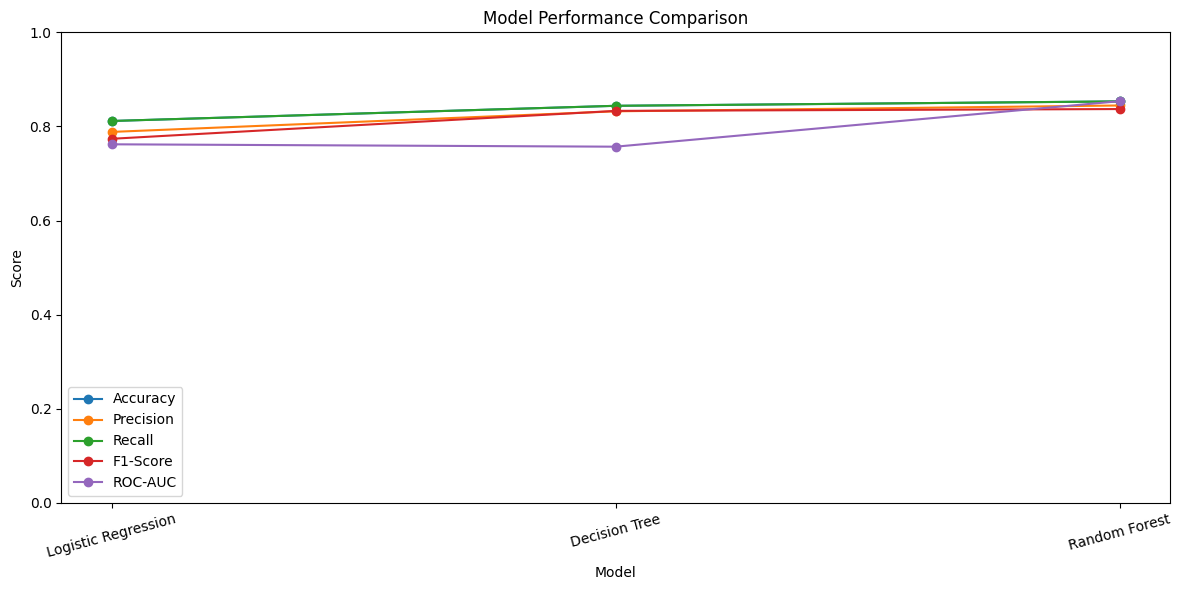

In [90]:
# ==========================================
# 29. Model Comparison Visualization
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt


# Create comparison DataFrame
comparison_df = pd.DataFrame(all_results)


print("=== Model Comparison Table ===")

print(
    comparison_df.to_string(index=False)
)


# ==========================================
# Plot Model Performance
# ==========================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

x = range(len(comparison_df))

plt.figure(figsize=(12, 6))

for metric in metrics:
    plt.plot(
        comparison_df["Model"],
        comparison_df[metric],
        marker="o",
        label=metric
    )

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.ylim(0, 1)

plt.legend()
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()